In [11]:
## Step 1: Import and inspect the data
import pandas as pd

df = pd.read_csv(r"C:\Users\kpodi\Downloads\insurance.csv")

df.head()
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


(1338, 7)

In [12]:
## Step 2: Data Cleaning
df.duplicated().sum()

np.int64(1)

In [13]:
df = df.drop_duplicates()

In [14]:
df.duplicated().sum()

np.int64(0)

In [19]:
## Step 3: Exploratory Data Analysis

# Summary statistics for insurance charges

average_charges = df['charges'].mean()
minimum_charges = df['charges'].min()
maximum_charges = df['charges'].max()

print("Average charges:", round(average_charges, 2))
print("Minimum charges:", round(minimum_charges, 2))
print("Maximum charges:", round(maximum_charges, 2))

Average charges: 13279.12
Minimum charges: 1121.87
Maximum charges: 63770.43


In [20]:
# Smoker vs Non-Smoker

df['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [21]:
# Average charges by sex
df.groupby('sex')['charges'].mean()

sex
female    12569.578844
male      13974.998864
Name: charges, dtype: float64

In [22]:
# Average charges by region
df.groupby('region')['charges'].mean()

region
northeast    13406.384516
northwest    12450.840844
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64

In [23]:
# Average charges by number of children
df.groupby('children')['charges'].mean()

children
0    12384.695344
1    12731.171832
2    15073.563734
3    15355.318367
4    13850.656311
5     8786.035247
Name: charges, dtype: float64

In [27]:
## Step 4: Data Transformation

# Creating BMI_Category - Underweight: below 18.5, Normal: 18.5 to 24.9, Overweight: 25 to 29.9, Obese: 30 or above

def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

df['bmi_category'] = df['bmi'].apply(bmi_category)

df[['bmi', 'bmi_category']].head()

,bmi,bmi_category
0,27.900,Overweight
1,33.770,Obese
2,33.000,Obese
3,22.705,Normal
4,28.880,Overweight


In [28]:
# Creating Age_Groups - Young: below 30, Middle-Aged: 30 to 49, Senior: 50 and above

def age_group(age):
    if age < 30:
        return 'Young'
    elif age < 50:
        return 'Middle-Aged'
    else:
        return 'Senior'

df['age_group'] = df['age'].apply(age_group)

df[['age', 'age_group']].head()

,age,age_group
0,19,Young
1,18,Young
2,28,Young
3,33,Middle-Aged
4,32,Middle-Aged


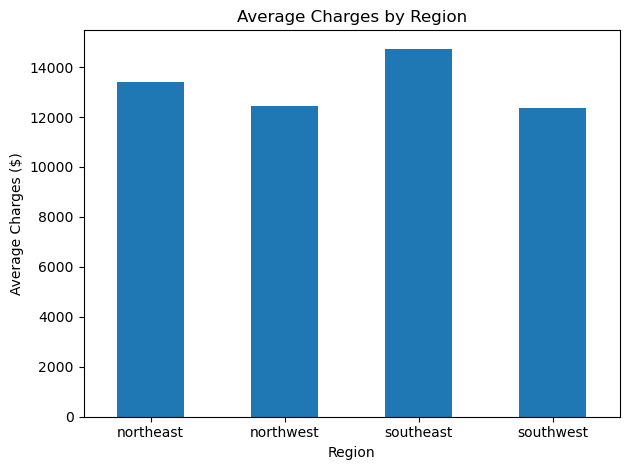

In [43]:
## Step 5: Visualisation with Matplotlib

import matplotlib.pyplot as plt

charges_by_region = df.groupby('region')['charges'].mean()

charges_by_region.plot(kind='bar')
plt.title('Average Charges by Region')
plt.ylabel('Average Charges ($)')
plt.xlabel('Region')
plt.xticks(rotation = 0)
plt.tight_layout()

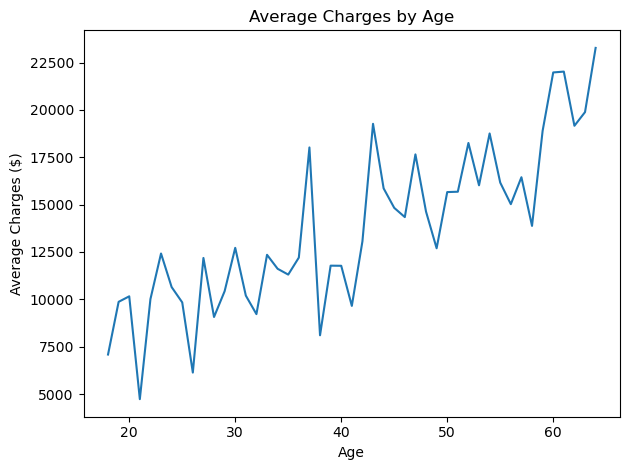

In [42]:
charges_by_age = df.groupby('age')['charges'].mean()

charges_by_age.plot(kind='line')
plt.title('Average Charges by Age')
plt.ylabel('Average Charges ($)')
plt.xlabel('Age')
plt.xticks(rotation = 0)
plt.tight_layout()

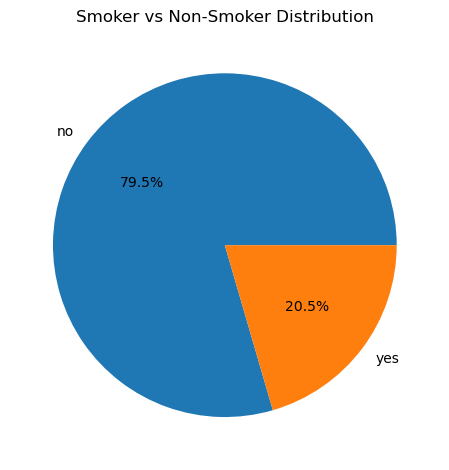

In [46]:
charges_by_smoker = df['smoker'].value_counts()

charges_by_smoker.plot(kind='pie', autopct='%1.1f%%')
plt.title('Smoker vs Non-Smoker Distribution')
plt.ylabel('')
plt.tight_layout()

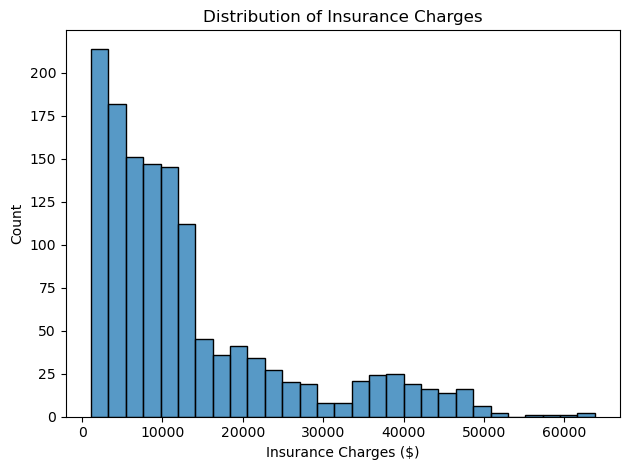

In [49]:
## Step 6: Visualisation with Seaborn

import seaborn as sns

sns.histplot(data=df, x='charges')
plt.title('Distribution of Insurance Charges')
plt.xlabel('Insurance Charges ($)')
plt.ylabel('Count')
plt.tight_layout()

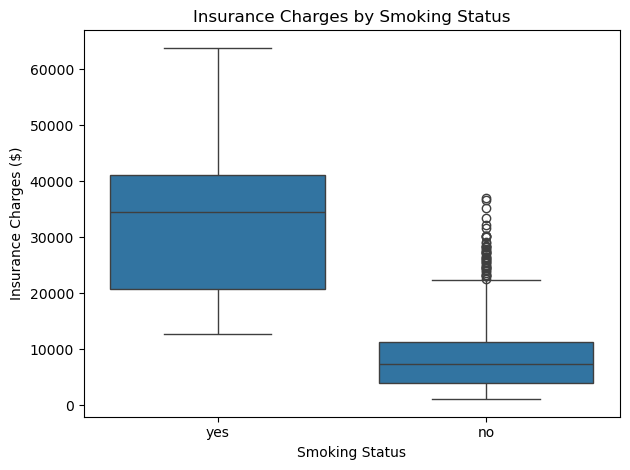

In [51]:
sns.boxplot(data=df, x='smoker', y='charges')
plt.title('Insurance Charges by Smoking Status')
plt.xlabel('Smoking Status')
plt.ylabel('Insurance Charges ($)')
plt.tight_layout()

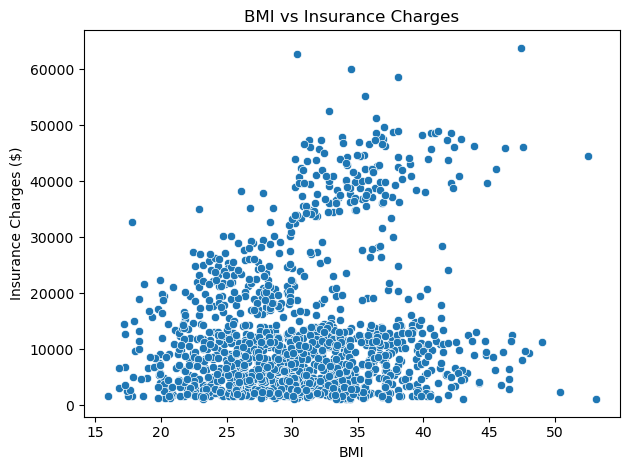

In [52]:
sns.scatterplot(data=df, x='bmi', y='charges')
plt.title('BMI vs Insurance Charges')
plt.xlabel('BMI')
plt.ylabel('Insurance Charges ($)')
plt.tight_layout()

In [53]:
df[['charges', 'age', 'children', 'bmi']].corr()

,charges,age,children,bmi
charges,1.000000,0.298308,0.067389,0.198401
age,0.298308,1.000000,0.041536,0.109344
children,0.067389,0.041536,1.000000,0.012755
bmi,0.198401,0.109344,0.012755,1.000000


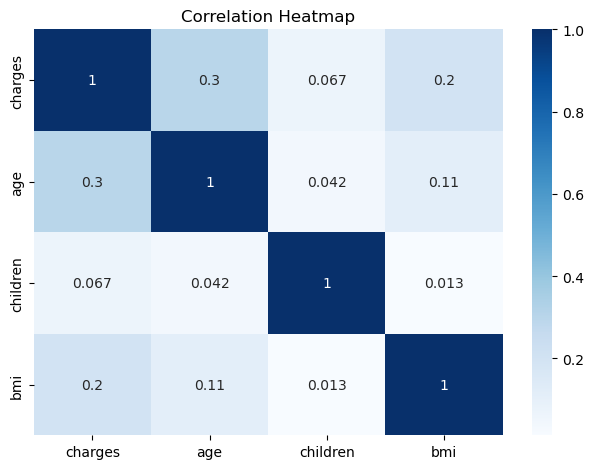

In [58]:
correlation_matrix = df[['charges', 'age', 'children', 'bmi']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='Blues')
plt.title('Correlation Heatmap')
plt.tight_layout()